# Insula HGA spatial map — loading specificity

Standalone figure notebook. Does **not** replace `functional_hga.ipynb`
(that notebook still uses hard `functional_cluster` argmax).

Here every assigned insula electrode contributes to all three cluster
densities, weighted by **loading specificity** and phase-window HGA.
Near-ties paint almost nothing; clean winners paint strongly.

That suppression is intentional for the **unique-territory** map, but mixed
electrodes are real and numerous. They are a fourth class, analyzed separately
(counts, Y–Z, gray density). A companion **proportion** map lets them paint as
blended hues instead of disappearing.

**Why not hard labels.** The same ~255 discovery electrodes appear in every
phase. Argmax membership therefore cannot move in space across rows. Phase
structure has to come from HGA. Specificity additionally down-weights
electrodes that mix two templates. Mixedness itself is electrode-level: it
does not change across the four phase rows.

**Score (insula discovery set).** \(H\) was learned from these electrodes, so
do not use reconstruction energy. From `channel_assignments.csv` loadings
\(a\):

$$
p_k = a_k / \sum_j a_j,\qquad
s_k = \max\bigl(p_k - \max_{j\neq k} p_j,\, 0\bigr)
$$

Per-phase KDE weight: \(w_{i,k} = s_{i,k}\,\max(\mathrm{HGA}_i, 0)\).
Surface RGB mix is unchanged (`densities_to_rgba`).

**Colors / names** come from `FUNCTION_COLORS` / `CLUSTER_LABELS` in
`src/nmf/waveform_analysis.py` (`sustain` gold, `motor` red, `sensory` blue).

**Output** (SVG only, under `img/functional_hga/`):

- `functional_hga_specificity_qc.svg` — \(s_k\) vs dominance
- `functional_hga_mixed_qc.svg` — mixed counts, mixture profile, Y–Z
- `functional_hga_spatial_phases_specificity.svg` — unique-territory map; gray dots = mixed
- `functional_hga_mixed_density.svg` — mixed-only gray density (one row)
- `functional_hga_spatial_phases_proportion.svg` — mixture map (blends)

HGA load and the Brain screenshots are the heavy cells. Run this notebook
yourself (same pattern as `wholebrain_projection_explore.ipynb`). Re-run from the config cell if `PROPORTION_COLS` / `is_mixed` are missing.


In [1]:
%matplotlib inline

import os
import sys
import warnings
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pyvista as pv
from IPython.display import display
from matplotlib.patches import Patch
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import (
    CLUSTER_LABELS,
    CLUSTER_ORDER,
    FUNCTION_COLORS,
    TASKS,
)
from src.paths import hga_results_dir, img_dir, nmf_assignments_path, save_svg

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")


Using notebook 3d backend.


In [2]:
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

fontsize = 7
fontdict = dict(fontsize=fontsize)

CLUSTERS = list(CLUSTER_ORDER)
CLUSTER_COLORS = {name: FUNCTION_COLORS[name] for name in CLUSTERS}
CLUSTER_RGB = np.array(
    [mcolors.to_rgb(CLUSTER_COLORS[name]) for name in CLUSTERS],
    dtype=float,
)
LOADING_COLS = [f"loading_{name}" for name in CLUSTERS]
PROPORTION_COLS = [f"proportion_{name}" for name in CLUSTERS]
SPECIFICITY_COLS = [f"specificity_{name}" for name in CLUSTERS]

PHASES = ["stimulus", "delay", "go", "response"]
DESCRIPTION = "Repeat"
MODALITY = "sound"
EXCLUDE_SUBJECTS = {"D0121"}

SPATIAL_TIME = {
    "stimulus": (0.0, 0.5),
    "delay": (0.0, 0.5),
    "go": (0.0, 0.5),
    "response": (0.0, 0.5),
}

DENSITY_BANDWIDTH = 5.0
DENSITY_MAX_DISTANCE = 6.0

# Winner beats runner-up by less than this → mixed (no real dominance).
# s_max = 0.2 is about dominance 0.6 in a two-way mix.
MIXED_SPECIFICITY_MAX = 0.20
MIXED_COLOR = "#6E6E6E"

NMF_ASSIGNMENTS = nmf_assignments_path()
recon_dir = "/cwork/ns458/ECoG_Recon/"
IMG_DIR = img_dir("functional_hga")
SPECIFICITY_QC_OUT = IMG_DIR / "functional_hga_specificity_qc.svg"
MIXED_QC_OUT = IMG_DIR / "functional_hga_mixed_qc.svg"
MIXED_DENSITY_OUT = IMG_DIR / "functional_hga_mixed_density.svg"
SPATIAL_SPECIFICITY_OUT = IMG_DIR / "functional_hga_spatial_phases_specificity.svg"
SPATIAL_PROPORTION_OUT = IMG_DIR / "functional_hga_spatial_phases_proportion.svg"

print("assignments", NMF_ASSIGNMENTS)
print("tasks", TASKS)
print("clusters", CLUSTERS)
print("FUNCTION_COLORS", CLUSTER_COLORS)
print(f"mixed if specificity_max < {MIXED_SPECIFICITY_MAX}")
print("out", SPATIAL_SPECIFICITY_OUT)


assignments /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/channel_assignments.csv
tasks ('PhonemeSequence', 'LexicalDelay', 'PictureNaming', 'SentenceRep')
clusters ['sustain', 'motor', 'sensory']
FUNCTION_COLORS {'sustain': '#C4A35A', 'motor': '#A9373B', 'sensory': '#2369BD'}
mixed if specificity_max < 0.2
out /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases_specificity.svg


## Loadings → specificity

Canonical `results/nmf/channel_assignments.csv`. Skip reconstruction energy:
these electrodes *are* the discovery set.

`dominance` is \(\max_k p_k\) (always ≥ 1/3). `specificity_max` is how far the
winner beats the runner-up. A three-way mix can have dominance ~0.35 and still
have no winner.


n=255 electrodes, 63 subjects
functional_cluster
sustain     74
motor      142
sensory     39
dtype: int64
specificity_max count    255.000
mean       0.421
std        0.284
min        0.007
25%        0.206
50%        0.353
75%        0.601
max        1.000
Name: specificity_max, dtype: float64
mixed (specificity_max < 0.2): 62 / 255 (24%)


,channel,subject,roi,hemi,x,y,z,component,functional_cluster,loading_sustain,...,proportion_sustain,proportion_motor,proportion_sensory,specificity_sustain,specificity_motor,specificity_sensory,specificity_max,specificity_winner,mix_pair,is_mixed
0,D0022_LMIF3-4,D0022,PIC,L,-36.8260,3.42880,-28.518790,1,sustain,0.356257,...,0.364071,0.313022,0.322907,0.041164,0.000000,0.0,0.041164,sustain,sustain–sensory,True
1,D0022_LPIF3-4,D0022,PIC,L,-33.9695,-3.02540,-19.234312,0,motor,0.122751,...,0.097171,0.580572,0.322257,0.000000,0.258316,0.0,0.258316,motor,motor–sensory,False
2,D0023_R2IF1-2,D0023,PIC,R,35.7033,7.35276,-0.947400,0,motor,0.000000,...,0.000000,0.580125,0.419875,0.000000,0.160249,0.0,0.160249,motor,motor–sensory,True
3,D0027_LAI1-2,D0027,AIC,L,-33.4346,25.11575,-21.905890,0,motor,0.477482,...,0.395774,0.524470,0.079756,0.000000,0.128696,0.0,0.128696,motor,motor–sustain,True
4,D0028_LAI1-2,D0028,AIC,L,-32.7839,29.09270,-30.771500,1,sustain,0.632800,...,0.732415,0.183301,0.084284,0.549114,0.000000,0.0,0.549114,sustain,sustain–motor,False


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_specificity_qc.svg


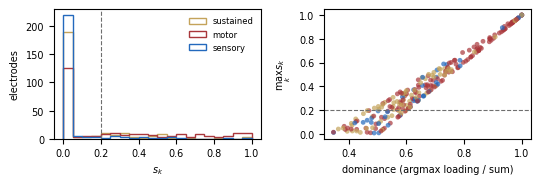

In [3]:
def specificity_from_loadings(loadings: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Non-negative one-vs-best-other contrast of loading proportions.

    ``s_k = max(p_k - max_{j≠k} p_j, 0)`` with ``p = a / sum(a)``.
    """
    loadings = np.clip(np.asarray(loadings, dtype=float), 0.0, None)
    total = loadings.sum(axis=1, keepdims=True)
    proportion = np.divide(
        loadings, total, out=np.zeros_like(loadings), where=total > 0
    )
    spec = np.zeros_like(proportion)
    for k in range(proportion.shape[1]):
        other = np.delete(proportion, k, axis=1)
        spec[:, k] = np.clip(proportion[:, k] - other.max(axis=1), 0.0, None)
    return proportion, spec


assignments = pd.read_csv(NMF_ASSIGNMENTS)
missing = [col for col in LOADING_COLS if col not in assignments.columns]
if missing:
    raise KeyError(f"{NMF_ASSIGNMENTS} missing {missing}")

assignments = assignments.loc[
    assignments["functional_cluster"].isin(CLUSTERS)
].copy()
proportion, spec = specificity_from_loadings(assignments[LOADING_COLS].to_numpy())
for col, values in zip(PROPORTION_COLS, proportion.T):
    assignments[col] = values
for col, values in zip(SPECIFICITY_COLS, spec.T):
    assignments[col] = values
assignments["specificity_max"] = spec.max(axis=1)
assignments["specificity_winner"] = np.array(CLUSTERS)[spec.argmax(axis=1)]
rank = np.argsort(-proportion, axis=1)
names = np.array(CLUSTERS)
assignments["mix_pair"] = [
    f"{names[i]}–{names[j]}" for i, j in zip(rank[:, 0], rank[:, 1])
]
assignments["is_mixed"] = assignments["specificity_max"] < MIXED_SPECIFICITY_MAX

keep_channels = set(assignments["channel"])
loading_map = assignments.set_index("channel")[
    LOADING_COLS
    + PROPORTION_COLS
    + SPECIFICITY_COLS
    + [
        "functional_cluster",
        "dominance",
        "specificity_max",
        "is_mixed",
        "mix_pair",
    ]
]

print(
    f"n={len(assignments)} electrodes, "
    f"{assignments['subject'].nunique()} subjects"
)
print(assignments.groupby("functional_cluster").size().reindex(CLUSTERS))
print("specificity_max", assignments["specificity_max"].describe().round(3))
n_mixed = int(assignments["is_mixed"].sum())
print(
    f"mixed (specificity_max < {MIXED_SPECIFICITY_MAX}): "
    f"{n_mixed} / {len(assignments)} ({100 * n_mixed / len(assignments):.0f}%)"
)
display(assignments.head())

fig, axes = plt.subplots(1, 2, figsize=(14 * cm, 5 * cm))
for name in CLUSTERS:
    axes[0].hist(
        assignments[f"specificity_{name}"],
        bins=20,
        range=(0, 1),
        histtype="step",
        color=CLUSTER_COLORS[name],
        label=CLUSTER_LABELS[name],
        lw=1.2,
    )
axes[0].axvline(MIXED_SPECIFICITY_MAX, color=MIXED_COLOR, lw=0.8, ls="--")
axes[0].set_xlabel(r"$s_k$", **fontdict)
axes[0].set_ylabel("electrodes", **fontdict)
axes[0].tick_params(labelsize=fontsize)
axes[0].legend(fontsize=fontsize - 1, frameon=False)

axes[1].scatter(
    assignments["dominance"],
    assignments["specificity_max"],
    s=12,
    c=assignments["functional_cluster"].map(CLUSTER_COLORS),
    alpha=0.7,
    linewidths=0,
)
axes[1].axhline(MIXED_SPECIFICITY_MAX, color=MIXED_COLOR, lw=0.8, ls="--")
axes[1].set_xlabel("dominance (argmax loading / sum)", **fontdict)
axes[1].set_ylabel(r"$\max_k s_k$", **fontdict)
axes[1].tick_params(labelsize=fontsize)
fig.tight_layout()
save_svg(fig, SPECIFICITY_QC_OUT)
print("Wrote", SPECIFICITY_QC_OUT)
plt.show()


## Mixed electrodes (no real dominance)

The specificity map **drops** these contacts: \(s_k \approx 0\) for all \(k\),
so they do not paint. That is the unique-territory statement, not a claim that
mixed electrodes are rare.

Call an electrode **mixed** when \(\max_k s_k < \) `MIXED_SPECIFICITY_MAX`
(default 0.20: winner is less than 20 percentage points ahead of the
runner-up). Tune that cutoff in the config cell.

Mixedness is a property of the NMF loadings, so it does **not** change across
phases. Analyze it once: who they are, which two templates they mix, and where
they sit. The four-row brain is the wrong place to look for mixed *dynamics*.


mixed 62 | specific 193 | cutoff specificity_max < 0.2
mixed by hard argmax:
 functional_cluster
sustain    22
motor      26
sensory    14
Name: count, dtype: int64
mixed by AIC/PIC:
 roi
AIC    38
PIC    24
Name: count, dtype: int64
runner-up pairs among mixed:
 mix_pair
motor–sustain      19
sustain–motor      13
sensory–sustain     9
sustain–sensory     9
motor–sensory       7
sensory–motor       5
Name: count, dtype: int64
mean p_k specific:
 proportion_sustain    0.279
proportion_motor      0.534
proportion_sensory    0.187
dtype: float64
mean p_k mixed:
 proportion_sustain    0.379
proportion_motor      0.353
proportion_sensory    0.268
dtype: float64
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_mixed_qc.svg


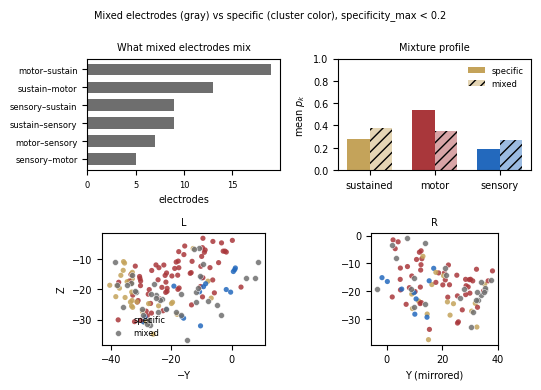

In [4]:
mixed = assignments.loc[assignments["is_mixed"]].copy()
specific = assignments.loc[~assignments["is_mixed"]].copy()

print(
    f"mixed {len(mixed)} | specific {len(specific)} | "
    f"cutoff specificity_max < {MIXED_SPECIFICITY_MAX}"
)
print("mixed by hard argmax:\n", mixed["functional_cluster"].value_counts().reindex(CLUSTERS))
print("mixed by AIC/PIC:\n", mixed["roi"].value_counts())
print("runner-up pairs among mixed:\n", mixed["mix_pair"].value_counts())
print("mean p_k specific:\n", specific[PROPORTION_COLS].mean().round(3))
print("mean p_k mixed:\n", mixed[PROPORTION_COLS].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14 * cm, 10 * cm))

pair_counts = mixed["mix_pair"].value_counts()
axes[0, 0].barh(
    np.arange(len(pair_counts)),
    pair_counts.to_numpy(),
    color=MIXED_COLOR,
    height=0.65,
)
axes[0, 0].set_yticks(np.arange(len(pair_counts)), labels=list(pair_counts.index))
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel("electrodes", **fontdict)
axes[0, 0].set_title("What mixed electrodes mix", **fontdict)
axes[0, 0].tick_params(labelsize=fontsize - 1)

x = np.arange(len(CLUSTERS))
width = 0.35
axes[0, 1].bar(
    x - width / 2,
    specific[PROPORTION_COLS].mean().to_numpy(),
    width,
    color=[CLUSTER_COLORS[name] for name in CLUSTERS],
    label="specific",
)
axes[0, 1].bar(
    x + width / 2,
    mixed[PROPORTION_COLS].mean().to_numpy(),
    width,
    color=[CLUSTER_COLORS[name] for name in CLUSTERS],
    alpha=0.45,
    hatch="///",
    label="mixed",
)
axes[0, 1].set_xticks(x, [CLUSTER_LABELS[name] for name in CLUSTERS])
axes[0, 1].set_ylabel(r"mean $p_k$", **fontdict)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Mixture profile", **fontdict)
axes[0, 1].tick_params(labelsize=fontsize)
axes[0, 1].legend(fontsize=fontsize - 1, frameon=False)

for hemi, ax, sign, xlabel in (
    ("L", axes[1, 0], -1, "−Y"),
    ("R", axes[1, 1], 1, "Y (mirrored)"),
):
    for frame, color, zorder, label in (
        (specific, None, 3, "specific"),
        (mixed, MIXED_COLOR, 4, "mixed"),
    ):
        hemi_frame = frame[frame["hemi"] == hemi]
        if hemi_frame.empty:
            continue
        ax.scatter(
            sign * hemi_frame["y"],
            hemi_frame["z"],
            s=14 if color is None else 18,
            c=(
                hemi_frame["functional_cluster"].map(CLUSTER_COLORS)
                if color is None
                else color
            ),
            alpha=0.85,
            linewidths=0.4 if color is not None else 0,
            edgecolors="white" if color is not None else "none",
            zorder=zorder,
            label=label if hemi == "L" else None,
        )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel, **fontdict)
    ax.set_title(hemi, **fontdict)
    ax.tick_params(labelsize=fontsize)
axes[1, 0].set_ylabel("Z", **fontdict)
axes[1, 0].legend(fontsize=fontsize - 1, frameon=False, loc="lower left")
fig.suptitle(
    f"Mixed electrodes (gray) vs specific (cluster color), "
    f"specificity_max < {MIXED_SPECIFICITY_MAX:g}",
    fontsize=fontsize,
)
fig.tight_layout()
save_svg(fig, MIXED_QC_OUT)
print("Wrote", MIXED_QC_OUT)
plt.show()


## Packaged HGA (Repeat + sound)

Same subset rule as NMF discovery: four concat-NMF tasks, Repeat, sound,
drop D0121. Membership is the assignment table, not per-phase significance.


In [ ]:
hga_paths = []
for task in TASKS:
    hga_paths.extend(
        BIDSPath(
            root=str(hga_results_dir(task)),
            datatype="HGA",
            suffix="time",
            check=False,
        ).match()
    )

frames = []
for path in tqdm(hga_paths, desc="load HGA"):
    df = pd.read_csv(path)
    if "channel" not in df.columns:
        continue
    df = df[df["channel"].isin(keep_channels)]
    if not df.empty:
        frames.append(df)

if not frames:
    raise FileNotFoundError(
        f"No HGA rows for NMF channels under results/hga/ for tasks={TASKS}"
    )

HGAs = pd.concat(frames, ignore_index=True)
HGAs.loc[HGAs.phase == "Resp", "phase"] = "Response"
HGAs.loc[HGAs.phase == "Audio", "phase"] = "Stimulus"
HGAs["phase"] = HGAs["phase"].astype(str).str.lower()

subset = HGAs[
    (HGAs.description == DESCRIPTION)
    & (HGAs.modality == MODALITY)
    & ~HGAs["subject"].isin(EXCLUDE_SUBJECTS)
].copy()
subset = subset.merge(loading_map.reset_index(), on="channel", how="inner")
subset["cluster_label"] = subset["functional_cluster"].map(CLUSTER_LABELS)

print("n channels", subset["channel"].nunique())
print(subset.groupby("functional_cluster")["channel"].nunique().reindex(CLUSTERS))
print("phases", sorted(subset.phase.unique()))
print(
    "tasks",
    sorted(subset.task.unique()) if "task" in subset.columns else "n/a",
)
display(subset.head())


load HGA:   0%|          | 0/1723 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3018468/3800199123.py:14: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3018468/3800199123.py:14: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3018468/3800199123.py:14: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3018468/3800199123.py:14: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3018468/3800199123.py:14: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(p

## Per-phase electrode table

Mean HGA in `SPATIAL_TIME`. Specificity is electrode-level and does not
change across phases; HGA does.


In [ ]:
def phase_spatial_table(frame: pd.DataFrame, phase: str) -> pd.DataFrame:
    t0, t1 = SPATIAL_TIME[phase]
    window = frame[(frame.phase == phase) & (frame.time > t0) & (frame.time < t1)]
    agg = {
        "HGA": ("value", "mean"),
        "x": ("x", "first"),
        "y": ("y", "first"),
        "z": ("z", "first"),
        "functional_cluster": ("functional_cluster", "first"),
        "hemi": ("hemi", "first"),
        "subject": ("subject", "first"),
        "mask": ("mask", "any"),
        "dominance": ("dominance", "first"),
        "is_mixed": ("is_mixed", "first"),
        "mix_pair": ("mix_pair", "first"),
        "specificity_max": ("specificity_max", "first"),
    }
    for col in SPECIFICITY_COLS + PROPORTION_COLS:
        agg[col] = (col, "first")
    spatial = window.groupby("channel", as_index=False).agg(**agg)
    return spatial.dropna(subset=["x", "y", "z"])


spatial_by_phase = {phase: phase_spatial_table(subset, phase) for phase in PHASES}
for phase, table in spatial_by_phase.items():
    weights = (
        np.clip(table["HGA"].to_numpy(float), 0.0, None)[:, None]
        * table[SPECIFICITY_COLS].to_numpy(float)
    )
    print(
        f"{phase}: n={len(table)} | "
        + ", ".join(
            f"{name} weight sum={weights[:, k].sum():.2f}"
            for k, name in enumerate(CLUSTERS)
        )
    )


stimulus: n=255 | sustain weight sum=2.31, motor weight sum=3.99, sensory weight sum=6.01
delay: n=255 | sustain weight sum=4.62, motor weight sum=2.41, sensory weight sum=0.89
go: n=255 | sustain weight sum=2.53, motor weight sum=7.92, sensory weight sum=0.23
response: n=255 | sustain weight sum=1.68, motor weight sum=29.32, sensory weight sum=2.37


## Insula pial surfaces


In [ ]:
labels = mne.read_labels_from_annot(
    subject="cvs_avg35_inMNI152",
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
insula_patterns = [
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
]

lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def get_insula_center(hemi: str, pial_coords: np.ndarray):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if not vertices:
        return None
    return pial_coords[vertices].mean(axis=0)


lh_insula_center = get_insula_center("lh", lh_pial_coords)
rh_insula_center = get_insula_center("rh", rh_pial_coords)


def make_insula_brains():
    lh_brain = Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi="lh",
        background="white",
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=0.05,
        size=(800, 800),
    )
    rh_brain = Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi="rh",
        background="white",
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=0.05,
        size=(800, 800),
    )
    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            brain = lh_brain if lab.hemi == "lh" else rh_brain
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.55)
    return lh_brain, rh_brain


def add_foci(brain, coords, tree, pial_coords, *, color, point_size=9.0):
    if len(coords) == 0:
        return
    _, indices = tree.query(coords)
    cloud = pv.PolyData(np.asarray(pial_coords[indices], dtype=float))
    brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=float(point_size),
        color=color,
        lighting=False,
    )


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


## Gaussian density RGB blend

Each specific electrode contributes to **all three** densities:
`dens[near] = kernel @ W` with `W.shape = (n_electrodes, 3)` and
\(W_{i,k}=s_{i,k}\max(\mathrm{HGA}_i,0)\).

Mixed electrodes (\(s_k\approx 0\)) do not paint. They are overlaid as gray
dots so you can see where the map is silent. Tune `DENSITY_BANDWIDTH` /
`DENSITY_MAX_DISTANCE` in the config cell.


2026-09-04 17:12:32.737 ( 133.275s) [    7F1D15497740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases_specificity.svg


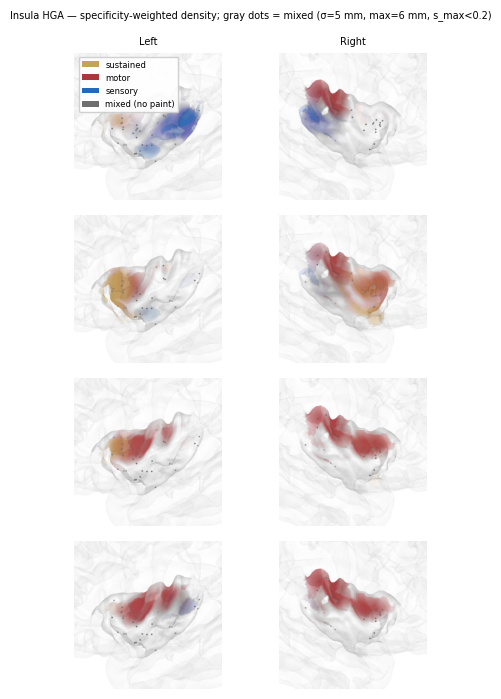

In [ ]:
def electrode_weights(spatial: pd.DataFrame) -> np.ndarray:
    spec = spatial[SPECIFICITY_COLS].to_numpy(dtype=float)
    hga = np.clip(spatial["HGA"].to_numpy(dtype=float), 0.0, None)
    return spec * hga[:, None]


def proportion_weights(spatial: pd.DataFrame) -> np.ndarray:
    prop = spatial[PROPORTION_COLS].to_numpy(dtype=float)
    hga = np.clip(spatial["HGA"].to_numpy(dtype=float), 0.0, None)
    return prop * hga[:, None]


def compute_cluster_densities(
    surface_coords: np.ndarray,
    electrode_coords: np.ndarray,
    weights: np.ndarray,
    *,
    bandwidth: float = DENSITY_BANDWIDTH,
    max_distance: float = DENSITY_MAX_DISTANCE,
) -> np.ndarray:
    """Return ``(n_vertices, n_clusters)`` Gaussian densities."""
    n_vertices = len(surface_coords)
    n_clusters = weights.shape[1] if len(weights) else len(CLUSTERS)
    dens = np.zeros((n_vertices, n_clusters), dtype=float)
    if len(electrode_coords) == 0:
        return dens
    weights = np.clip(np.asarray(weights, dtype=float), 0.0, None)
    distances = cdist(surface_coords, electrode_coords)
    near = distances.min(axis=1) < max_distance
    if not near.any():
        return dens
    kernel = np.exp(-distances[near] ** 2 / (2.0 * bandwidth ** 2))
    dens[near] = kernel @ weights
    return dens


def densities_to_rgba(
    dens: np.ndarray,
    colors_rgb: np.ndarray = CLUSTER_RGB,
    *,
    alpha_percentile: float = 95.0,
) -> np.ndarray:
    total = dens.sum(axis=1)
    mix = np.zeros_like(dens)
    nonzero = total > 0
    mix[nonzero] = dens[nonzero] / total[nonzero, None]
    rgb = mix @ colors_rgb
    alpha = np.zeros(len(total), dtype=float)
    if nonzero.any():
        scale = float(np.percentile(total[nonzero], alpha_percentile))
        alpha = np.clip(total / max(scale, 1e-12), 0.0, 1.0)
    return np.concatenate([rgb, alpha[:, None]], axis=1)


def add_density_rgba_mesh(
    brain, hemi: str, pial_coords: np.ndarray, rgba: np.ndarray
) -> None:
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    cells = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), faces]
    ).ravel()
    mesh = pv.PolyData(np.asarray(pial_coords, dtype=float), cells)
    mesh["rgba"] = (np.clip(rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    brain._renderer.plotter.add_mesh(
        mesh,
        scalars="rgba",
        rgba=True,
        lighting=False,
        smooth_shading=True,
    )


def render_phase_brains_density(
    spatial: pd.DataFrame,
    weights: np.ndarray,
    *,
    overlay_mixed: bool = True,
):
    lh_brain, rh_brain = make_insula_brains()
    cord = spatial[["x", "y", "z"]].to_numpy(float)
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    dens_lh = compute_cluster_densities(
        lh_pial_coords, cord[mask_lh], weights[mask_lh]
    )
    dens_rh = compute_cluster_densities(
        rh_pial_coords, cord[mask_rh], weights[mask_rh]
    )
    add_density_rgba_mesh(
        lh_brain, "lh", lh_pial_coords, densities_to_rgba(dens_lh)
    )
    add_density_rgba_mesh(
        rh_brain, "rh", rh_pial_coords, densities_to_rgba(dens_rh)
    )
    if overlay_mixed and "is_mixed" in spatial.columns:
        mixed_cord = cord[spatial["is_mixed"].to_numpy()]
        add_foci(
            lh_brain,
            mixed_cord[mixed_cord[:, 0] < 0],
            lh_tree,
            lh_pial_coords,
            color=MIXED_COLOR,
        )
        add_foci(
            rh_brain,
            mixed_cord[mixed_cord[:, 0] > 0],
            rh_tree,
            rh_pial_coords,
            color=MIXED_COLOR,
        )

    lh_brain.show_view(
        azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center
    )
    rh_brain.show_view(
        azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center
    )
    lh_img = lh_brain.screenshot(mode="rgb")
    rh_img = rh_brain.screenshot(mode="rgb")
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img


fig, axes = plt.subplots(
    nrows=len(PHASES),
    ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(
                0.5, 0.5, f"No data ({phase})", ha="center", va="center"
            )
            axes[row, col].axis("off")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lh_img, rh_img = render_phase_brains_density(
            spatial, electrode_weights(spatial), overlay_mixed=True
        )

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title("Left" if row == 0 else "", fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis("off")
    axes[row, 1].set_title("Right" if row == 0 else "", fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[name], label=CLUSTER_LABELS[name])
    for name in CLUSTERS
]
legend_elements.append(Patch(facecolor=MIXED_COLOR, label="mixed (no paint)"))
axes[0, 0].legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=fontsize - 1,
    framealpha=0.9,
)
fig.suptitle(
    "Insula HGA — specificity-weighted density; gray dots = mixed "
    f"(σ={DENSITY_BANDWIDTH:g} mm, max={DENSITY_MAX_DISTANCE:g} mm, "
    f"s_max<{MIXED_SPECIFICITY_MAX:g})",
    fontsize=fontsize,
)
fig.tight_layout()
save_svg(fig, SPATIAL_SPECIFICITY_OUT)
print("Wrote", SPATIAL_SPECIFICITY_OUT.resolve())
plt.show()


## Mixed as their own density

One row, not four: mixedness does not depend on phase. Gray KDE of electrodes
with `is_mixed`. If this cloud sits on cluster boundaries, mixed is spatial
overlap; if it is sprinkled through all three territories, mixed is a
within-site mixture.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_mixed_density.svg


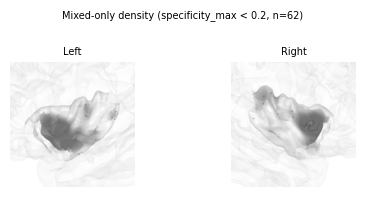

In [ ]:
def render_mixed_density(frame: pd.DataFrame):
    lh_brain, rh_brain = make_insula_brains()
    cord = frame[["x", "y", "z"]].to_numpy(float)
    weights = frame["is_mixed"].to_numpy(dtype=float)[:, None]
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0
    gray_rgb = np.array([mcolors.to_rgb(MIXED_COLOR)], dtype=float)
    dens_lh = compute_cluster_densities(
        lh_pial_coords, cord[mask_lh], weights[mask_lh]
    )
    dens_rh = compute_cluster_densities(
        rh_pial_coords, cord[mask_rh], weights[mask_rh]
    )
    add_density_rgba_mesh(
        lh_brain, "lh", lh_pial_coords, densities_to_rgba(dens_lh, gray_rgb)
    )
    add_density_rgba_mesh(
        rh_brain, "rh", rh_pial_coords, densities_to_rgba(dens_rh, gray_rgb)
    )
    is_mixed = frame["is_mixed"].to_numpy()
    add_foci(
        lh_brain,
        cord[mask_lh & is_mixed],
        lh_tree,
        lh_pial_coords,
        color=MIXED_COLOR,
        point_size=8,
    )
    add_foci(
        rh_brain,
        cord[mask_rh & is_mixed],
        rh_tree,
        rh_pial_coords,
        color=MIXED_COLOR,
        point_size=8,
    )
    lh_brain.show_view(
        azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center
    )
    rh_brain.show_view(
        azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center
    )
    lh_img = lh_brain.screenshot(mode="rgb")
    rh_img = rh_brain.screenshot(mode="rgb")
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mixed_lh, mixed_rh = render_mixed_density(assignments)

fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5 * cm))
axes[0].imshow(mixed_lh)
axes[0].axis("off")
axes[0].set_title("Left", fontsize=fontsize)
axes[1].imshow(mixed_rh)
axes[1].axis("off")
axes[1].set_title("Right", fontsize=fontsize)
fig.suptitle(
    f"Mixed-only density (specificity_max < {MIXED_SPECIFICITY_MAX:g}, "
    f"n={int(assignments['is_mixed'].sum())})",
    fontsize=fontsize,
)
fig.tight_layout()
save_svg(fig, MIXED_DENSITY_OUT)
print("Wrote", MIXED_DENSITY_OUT.resolve())
plt.show()


## Companion: proportion-weighted density

Same Gaussian, but \(w_{i,k}=p_{i,k}\,\max(\mathrm{HGA}_i,0)\). Mixed electrodes
now **paint as blends** (olive, purple, brown) instead of vanishing. Compare
with the specificity map: unique territories should stay similar; mixed sites
are the extra intermediate color.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases_proportion.svg


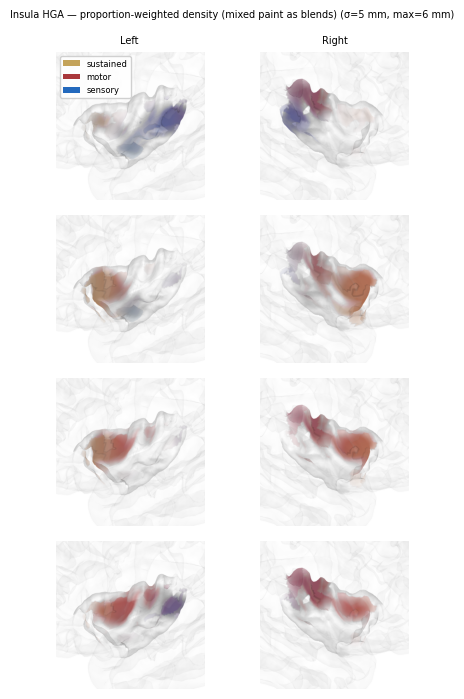

In [ ]:
fig, axes = plt.subplots(
    nrows=len(PHASES),
    ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(
                0.5, 0.5, f"No data ({phase})", ha="center", va="center"
            )
            axes[row, col].axis("off")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lh_img, rh_img = render_phase_brains_density(
            spatial, proportion_weights(spatial), overlay_mixed=False
        )

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title("Left" if row == 0 else "", fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis("off")
    axes[row, 1].set_title("Right" if row == 0 else "", fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[name], label=CLUSTER_LABELS[name])
    for name in CLUSTERS
]
axes[0, 0].legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=fontsize - 1,
    framealpha=0.9,
)
fig.suptitle(
    "Insula HGA — proportion-weighted density (mixed paint as blends) "
    f"(σ={DENSITY_BANDWIDTH:g} mm, max={DENSITY_MAX_DISTANCE:g} mm)",
    fontsize=fontsize,
)
fig.tight_layout()
save_svg(fig, SPATIAL_PROPORTION_OUT)
print("Wrote", SPATIAL_PROPORTION_OUT.resolve())
plt.show()
